# Honeywell Temperature Alarm Prediction Model
## Phase 1: Detailed Exploratory Data Analysis (EDA) & Feature Engineering

This notebook provides a comprehensive analysis of the plant sensor dataset and implements a robust time-series feature engineering pipeline. The goal is to build a machine learning model to predict overhead temperature alarms (**`03TIC_1023.PV` >= 21.0°C**) at multiple future horizons (15m, 30m, and 60m).

---

# Part 1: Exploratory Data Analysis (EDA)

### Why do we do EDA on industrial sensor data?
Before building any machine learning model, we must verify the physical characteristics and health of the data. In process operations:
1. **Sensor Gaps & Shutdowns**: Plants go down for maintenance (trips/turnarounds). Training models on shutdown data or computing rolling averages across a 2-week gap causes major math errors.
2. **Data Sampling Rate**: We must confirm if the data is sampled regularly (e.g. every minute) to know if row-shifting aligns with actual physical time.
3. **Alarm Distribution (Class Imbalance)**: Alarms are rare events. We must measure exactly how often they happen to choose the right model validation metrics.
4. **Physical Interdependencies**: Sensors are coupled (e.g. pressure affects boiling point and temperature). We must identify these correlations to select the best predictor variables.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for client presentations
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("muted")

# Paths
DATA_PATH = r"03TIC_1023_PVHI/03TIC_1023_PVHI/03TIC_1023_Final_merged_TripDataRemoved.parquet"
TRIP_CSV_PATH = r"03TIC_1023_PVHI/03TIC_1023_PVHI/Final_Trip_Duration - Copy.csv"
ALARM_THRESHOLD = 21.0
TARGET_COL = '03TIC_1023.PV'

### Step 1.1: Loading the Data & Schema Verification
**Why:** Confirm the dataset dimensions, verify column names, and check for missing values.

In [2]:
print("Loading dataset...")
df = pd.read_parquet(DATA_PATH)
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
df = df.sort_values('TimeStamp').reset_index(drop=True)

print(f"\n[Insight] Dataset Dimensions: {df.shape[0]:,} rows (minutes) and {df.shape[1]} columns.")
print(f"[Insight] Time Range: {df['TimeStamp'].min()} to {df['TimeStamp'].max()}")
print(f"\nColumns in dataset:")
print(list(df.columns))

Loading dataset...

[Insight] Dataset Dimensions: 2,019,221 rows (minutes) and 20 columns.
[Insight] Time Range: 2022-01-03 22:45:00 to 2026-01-09 23:29:00

Columns in dataset:
['TimeStamp', '02FI_1000.PV', '03FIC_1085.PV', '03LIC_1016.PV', '03LIC_1034.PV', '03PDI_1020.PV', '03PDI_1077.PV', '03PIC_1013.PV', '03PIC_1023.PV', '03PIC_1068.PV', '03PI_1409.PV', '03TIC_1009.PV', '03TIC_1023.PV', '03TIC_1145.PV', '03TI_1002.PV', '03TI_1005.PV', '03TI_1015.PV', '03TI_1024.PV', '03TI_1081.PV', '03TI_1108.PV']


### Step 1.2: Checking Missing Values (Data Integrity)
**Why:** Missing sensor data (NaNs) can break machine learning models. We need to identify if we have major sensor outages.

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct.round(4)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage (%)', ascending=False)

print("Columns with missing values:")
if len(missing_df) > 0:
    display(missing_df)
    print("\n[Insight] Data is exceptionally clean. The highest missing rate is only 0.15% in 03TI_1002.PV. The target has only 4 missing values.")
else:
    print("No missing values found! The dataset is complete.")

Columns with missing values:


,Missing Count,Percentage (%)
03TI_1002.PV,3041,0.1506
02FI_1000.PV,669,0.0331
03FIC_1085.PV,315,0.0156
03PDI_1077.PV,12,0.0006
03TIC_1145.PV,11,0.0005
03PIC_1013.PV,11,0.0005
03LIC_1016.PV,8,0.0004
03PIC_1068.PV,8,0.0004
03TI_1108.PV,8,0.0004
03PDI_1020.PV,8,0.0004



[Insight] Data is exceptionally clean. The highest missing rate is only 0.15% in 03TI_1002.PV. The target has only 4 missing values.


### Step 1.3: Confirming Timeline Continuity & Handling Gaps from Trips
**Why:** Chemical processes are continuous, but shutdowns introduce huge gaps. We must verify if the shutdown periods listed in the plant's trip log (`Final_Trip_Duration - Copy.csv`) are already removed from our dataset.

In [4]:
# Calculate time intervals between rows
time_diffs = df['TimeStamp'].diff().dropna()
print("Summary of time intervals between consecutive rows:")
print(time_diffs.describe())
print(f"\nMedian interval: {time_diffs.median()}")
print(f"Maximum interval: {time_diffs.max()}")

# Check overlap with trip sheet
trips_df = pd.read_csv(TRIP_CSV_PATH)
trips_df['Start Date'] = pd.to_datetime(trips_df['Start Date'])
trips_df['Stop Date'] = pd.to_datetime(trips_df['Stop Date'])

overlap_count = 0
for idx, row in trips_df.iterrows():
    stop_d = row['Stop Date']
    start_d = row['Start Date']
    if start_d < stop_d:  # Ensure correct chronological order
        start_d, stop_d = stop_d, start_d
    cnt = ((df['TimeStamp'] >= stop_d) & (df['TimeStamp'] <= start_d)).sum()
    if cnt > 0:
        overlap_count += cnt

print(f"\n[Insight] Rows in dataset that fall within trip periods: {overlap_count}")
print("[Insight] Since overlap is exactly 0, it is confirmed that all trip/shutdown periods have already been removed from this parquet file. Gaps exist in the timeline (max gap = 18.5 days).")

Summary of time intervals between consecutive rows:
count                      2019220
mean     0 days 00:01:02.772476500
std      0 days 00:22:18.470634301
min                0 days 00:01:00
25%                0 days 00:01:00
50%                0 days 00:01:00
75%                0 days 00:01:00
max               18 days 14:22:00
Name: TimeStamp, dtype: object

Median interval: 0 days 00:01:00
Maximum interval: 18 days 14:22:00

[Insight] Rows in dataset that fall within trip periods: 0
[Insight] Since overlap is exactly 0, it is confirmed that all trip/shutdown periods have already been removed from this parquet file. Gaps exist in the timeline (max gap = 18.5 days).


### Step 1.4: Alarm Episode Analysis (Class Imbalance & Durations)
**Why:** To determine how frequently the process goes into alarm state, how long the alarm episodes last, and if they are sudden spikes or sustained upsets.

In [5]:
# Flag alarm rows
df['in_alarm'] = df[TARGET_COL] >= ALARM_THRESHOLD
alarm_ratio = df['in_alarm'].mean() * 100
print(f"Total rows in alarm state: {df['in_alarm'].sum():,} out of {len(df):,} ({alarm_ratio:.4f}%)")

# Detect contiguous alarm episodes
df['alarm_change'] = df['in_alarm'].ne(df['in_alarm'].shift())
df['episode_id'] = df['alarm_change'].cumsum()

alarm_episodes = df[df['in_alarm']].groupby('episode_id').agg(
    start_time=('TimeStamp', 'min'),
    end_time=('TimeStamp', 'max'),
    duration_minutes=('TimeStamp', lambda x: (x.max() - x.min()).total_seconds() / 60.0 + 1.0),
    max_temp=(TARGET_COL, 'max'),
    count=('TimeStamp', 'count')
).reset_index(drop=True)

print(f"\nTotal distinct alarm episodes detected: {len(alarm_episodes)}")
print("\nSummary statistics of alarm episode durations (minutes):")
display(alarm_episodes['duration_minutes'].describe())

print("\n[Insight] The median alarm duration is only 3 minutes (short thermal spikes). However, the mean is 40 minutes because of major upsets lasting up to 9.3 hours (562 minutes). The model must focus on predicting these long-duration upsets.")

Total rows in alarm state: 62,837 out of 2,019,221 (3.1119%)

Total distinct alarm episodes detected: 1561

Summary statistics of alarm episode durations (minutes):


count    1561.000000
mean       40.254965
std        96.715889
min         1.000000
25%         2.000000
50%         3.000000
75%        14.000000
max       562.000000
Name: duration_minutes, dtype: float64


[Insight] The median alarm duration is only 3 minutes (short thermal spikes). However, the mean is 40 minutes because of major upsets lasting up to 9.3 hours (562 minutes). The model must focus on predicting these long-duration upsets.


### Step 1.5: Physical Sensor Correlations
**Why:** To understand the thermodynamic coupling of the column. This tells us which upstream variables will act as early warning indicators.

Correlation of Features with Target Tag (03TIC_1023.PV):


03TIC_1023.PV    1.000000
03TI_1024.PV     0.983974
03TI_1015.PV     0.980403
03PIC_1023.PV    0.965368
03TI_1081.PV     0.728774
03PIC_1013.PV    0.567472
03TIC_1009.PV    0.558848
03TI_1108.PV     0.541060
03TI_1005.PV     0.525967
03TI_1002.PV     0.465672
03FIC_1085.PV    0.363502
03PDI_1020.PV    0.169405
02FI_1000.PV     0.103972
03LIC_1034.PV    0.018560
03PDI_1077.PV    0.011173
03LIC_1016.PV   -0.062471
03TIC_1145.PV   -0.090961
03PI_1409.PV    -0.195313
03PIC_1068.PV   -0.204816
Name: 03TIC_1023.PV, dtype: float64

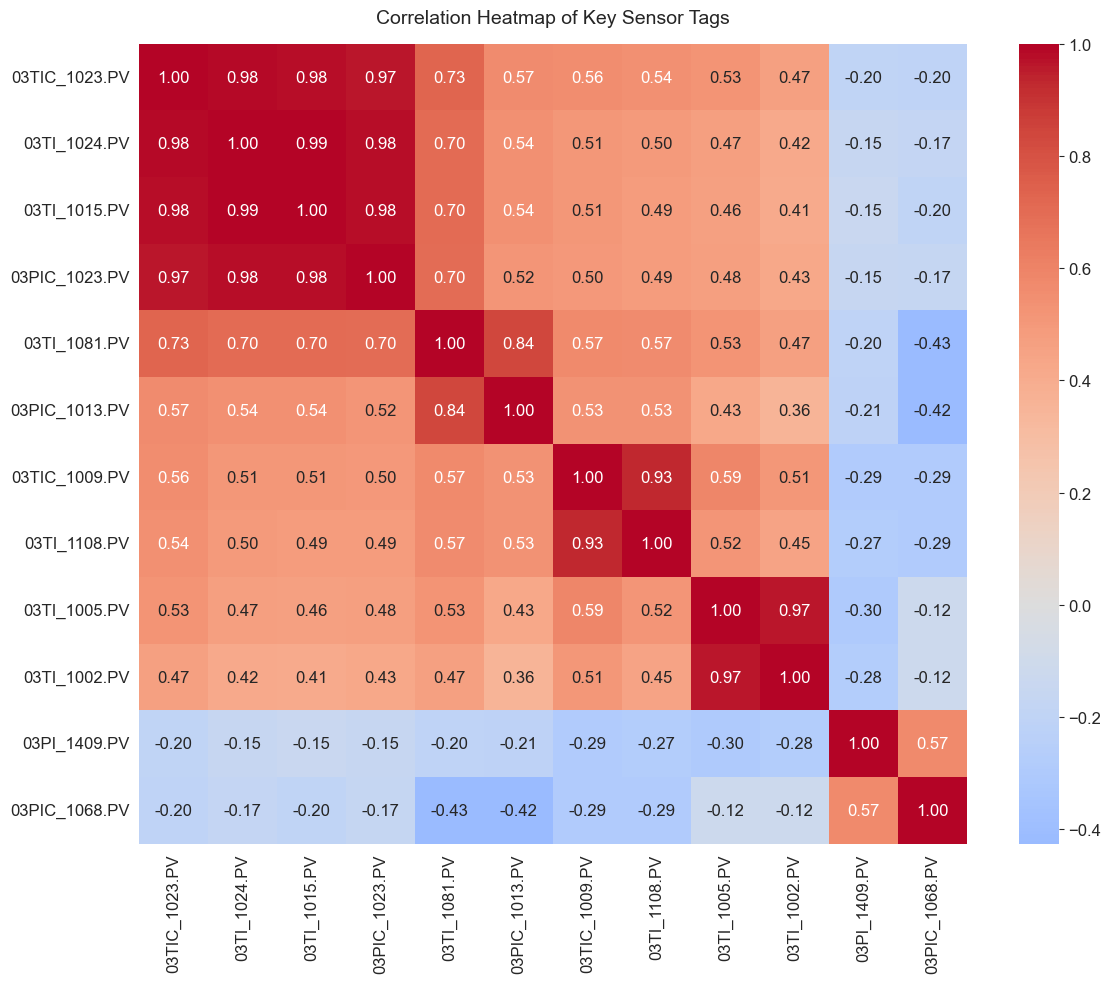


[Insight] Physical Interdependencies:
1. 03TI_1024.PV (Inlet Temperature) has a 0.98 correlation. A rising inlet temp directly heats up the overhead.
2. 03PIC_1023.PV (Separator Pressure) has a 0.96 correlation. A pressure rise raises the boiling point and temperature inside the column.
These tags will be key drivers for our early warning models.


In [6]:
numeric_cols = [c for c in df.columns if c not in ['TimeStamp', 'in_alarm', 'alarm_change', 'episode_id']]
correlations = df[numeric_cols].corr()[TARGET_COL].sort_values(ascending=False)

print("Correlation of Features with Target Tag (03TIC_1023.PV):")
display(correlations)

# Plot Correlation Heatmap for Top 10 correlated features
top_correlated = correlations.index[:10].tolist() + correlations.index[-2:].tolist()
corr_matrix = df[top_correlated].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar=True)
plt.title("Correlation Heatmap of Key Sensor Tags", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\n[Insight] Physical Interdependencies:")
print("1. 03TI_1024.PV (Inlet Temperature) has a 0.98 correlation. A rising inlet temp directly heats up the overhead.")
print("2. 03PIC_1023.PV (Separator Pressure) has a 0.96 correlation. A pressure rise raises the boiling point and temperature inside the column.")
print("These tags will be key drivers for our early warning models.")

--- 
# Part 2: Feature Engineering

### Why do we need feature engineering in time-series?
In process control, the current value of a sensor (e.g. 20.5°C at time $t$) is not enough. To predict what will happen in 30 minutes, the model needs to understand:
1. **Velocity (Derivative)**: Is the temperature rising or falling? How fast?
2. **Baselines (Moving Average)**: Is the system operating at a higher average temperature today than yesterday?
3. **Volatility (Noise/Stability)**: Are the pressures oscillating rapidly (sign of instability) or stable?
4. **History (Lags)**: What were the sensor values 10, 30, or 60 minutes ago?

By constructing these mathematical representations of plant physics, we give the model the capacity to project trends into the future.

### Step 2.1: Regular Time Alignment (Solving the Gap Problem)
**Why:** Because trip periods were removed, there are gaps in our dataframe index. If we simply shift rows (e.g., `.shift(15)`), the shift will cross the maintenance gap, representing days of shutdown instead of 15 minutes of operating time. 

**How:** We set `TimeStamp` as the index and reindex the data to a regular 1-minute grid. This places `NaN` values during the shutdown gaps. Rolling calculations will evaluate over true physical time. Gaps remain as NaNs, which we will drop later.

In [7]:
print("Setting index and reindexing to a regular 1-minute grid...")
df_aligned = df.set_index('TimeStamp')
full_idx = pd.date_range(start=df_aligned.index.min(), end=df_aligned.index.max(), freq='1min')
df_aligned = df_aligned.reindex(full_idx)
df_aligned.index.name = 'TimeStamp'

print(f"Raw rows: {len(df):,}")
print(f"Reindexed grid rows: {len(df_aligned):,} (Inserted {len(df_aligned) - len(df):,} NaN rows during shutdown gaps)")

Setting index and reindexing to a regular 1-minute grid...
Raw rows: 2,019,221
Reindexed grid rows: 2,112,525 (Inserted 93,304 NaN rows during shutdown gaps)


### Step 2.2: Engineering Lags, Rolling Statistics, and Derivatives
We create the following feature groups on our top 5 correlated tags:
1. **Lags**: Captures history ($X_{t-1}, X_{t-2}, X_{t-5}$, etc.).
2. **Rolling Mean**: Smooths noise to capture baseline temperature creep.
3. **Rolling Standard Deviation**: Captures process oscillations (instability).
4. **Rolling Max / Min**: Captures extreme bounds inside windows.
5. **Differences (Rates of Change)**: The velocity of the variables ($X_t - X_{t-5}$, etc.).

In [9]:
key_cols = ['03TIC_1023.PV', '03TI_1024.PV', '03TI_1015.PV', '03PIC_1023.PV', '03TI_1081.PV']
df_features = df_aligned.copy()

# 1. Ambient Time Features
df_features['hour'] = df_features.index.hour
df_features['month'] = df_features.index.month
df_features['dayofweek'] = df_features.index.dayofweek

# 2. Lag Features
print("Calculating lags...")
for col in key_cols:
    for lag in [1, 2, 5, 10, 15, 30, 60]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)
        
# 3. Rolling Features (Mean, Std, Max, Min over 10m, 30m, and 60m)
print("Calculating rolling windows...")
for col in key_cols:
    for window in [10, 30, 60]:
        df_features[f'{col}_roll_mean_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).mean()
        df_features[f'{col}_roll_std_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).std()
        df_features[f'{col}_roll_max_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).max()
        df_features[f'{col}_roll_min_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).min()

# 4. Rate-of-Change / Difference Features
print("Calculating rates of change...")
for col in key_cols:
    for diff in [5, 15, 30]:
        df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)

# Print shape
print(f"\n[Insight] Engineered a total of {df_features.shape[1] - df_aligned.shape[1]} new features.")
print(f"Feature matrix dimensions: {df_features.shape}")

Calculating lags...
Calculating rolling windows...
Calculating rates of change...


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)
C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)
C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usu


[Insight] Engineered a total of 113 new features.
Feature matrix dimensions: (2112525, 135)


C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)
C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)
C:\Users\Ajay_ML\AppData\Local\Temp\ipykernel_12824\2156353473.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usu

In [22]:
print(f"df shape :{df.shape}")

print(f"df columns :{df.columns}")

print(f"df_features shape : {df_features.shape}")

print(f"df features columns : {df_features.columns}")


df shape :(2019221, 23)
df columns :Index(['TimeStamp', '02FI_1000.PV', '03FIC_1085.PV', '03LIC_1016.PV',
       '03LIC_1034.PV', '03PDI_1020.PV', '03PDI_1077.PV', '03PIC_1013.PV',
       '03PIC_1023.PV', '03PIC_1068.PV', '03PI_1409.PV', '03TIC_1009.PV',
       '03TIC_1023.PV', '03TIC_1145.PV', '03TI_1002.PV', '03TI_1005.PV',
       '03TI_1015.PV', '03TI_1024.PV', '03TI_1081.PV', '03TI_1108.PV',
       'in_alarm', 'alarm_change', 'episode_id'],
      dtype='object')
df_features shape : (2112525, 135)
df features columns : Index(['02FI_1000.PV', '03FIC_1085.PV', '03LIC_1016.PV', '03LIC_1034.PV',
       '03PDI_1020.PV', '03PDI_1077.PV', '03PIC_1013.PV', '03PIC_1023.PV',
       '03PIC_1068.PV', '03PI_1409.PV',
       ...
       '03TI_1024.PV_diff_30', '03TI_1015.PV_diff_5', '03TI_1015.PV_diff_15',
       '03TI_1015.PV_diff_30', '03PIC_1023.PV_diff_5', '03PIC_1023.PV_diff_15',
       '03PIC_1023.PV_diff_30', '03TI_1081.PV_diff_5', '03TI_1081.PV_diff_15',
       '03TI_1081.PV_diff_30'],
   

--- 
# Part 3: Validation Strategy (Chronological Splitting)

### Why do we avoid random splits in time-series?
In standard ML, datasets are split randomly (e.g. 80% train, 20% test). In time series, this causes **extreme data leakage**:
* Because the temperature at minute $t$ is 99% correlated with minute $t-1$, a model that trains on $t-1$ and $t+1$ will easily "guess" $t$ without learning any underlying physical process rules.
* This leads to fake 99% accuracies in testing, which collapses to 10% in production when predicting unseen future data.

### Our Splitting Solution:
We split the data strictly chronologically. This ensures that the model is only tested on "the future" relative to what it has trained on:
- **Training Set (60%)**: Jan 2022 to Dec 2024 (~3 years) - Used to build the trees.
- **Validation Set (20%)**: Jan 2025 to June 2025 (~6 months) - Used for early stopping.
- **Test Set (20%)**: July 2025 to Jan 2026 (~6 months) - Saved for final validation.

In [23]:
train_end = pd.to_datetime('2024-12-31 23:59:00')
val_end = pd.to_datetime('2025-06-30 23:59:00')

train_size = len(df_features.loc[:train_end])
val_size = len(df_features.loc[train_end + pd.Timedelta(minutes=1):val_end])
test_size = len(df_features.loc[val_end + pd.Timedelta(minutes=1):])

print(f"Training rows (2022-2024): {train_size:,} ({train_size/len(df_features)*100:.1f}%)")
print(f"Validation rows (H1 2025): {val_size:,} ({val_size/len(df_features)*100:.1f}%)")
print(f"Testing rows (H2 2025-Jan 2026): {test_size:,} ({test_size/len(df_features)*100:.1f}%)")

Training rows (2022-2024): 1,573,995 (74.5%)
Validation rows (H1 2025): 260,640 (12.3%)
Testing rows (H2 2025-Jan 2026): 277,890 (13.2%)


--- 
# Next Steps & Forward Action Plan

To transition this analysis into a production-ready deployment, our next steps include:

```mermaid
graph TD
    A["1. Model Training (Multi-Horizon)"] --> B["2. F1-Score Threshold Optimization"]
    B --> C["3. Streamlit Real-Time Simulator"]
    C --> D["4. Live Historian Integration"]
```

### 1. Model Training (Multi-Horizon LightGBM)
* **Action**: Train three LightGBM gradient-boosted decision tree regressors to predict the future temperature values at $t+15$, $t+30$, and $t+60$ minutes.
* **Why**: Decision trees are fast, handle collinear sensor inputs, and natively handle missing value gaps during maintenance without imputation.

### 2. Threshold & F1-Score Optimization
* **Action**: Evaluate predictions against the **21.0°C** limit and optimize decision thresholds to maximize the **F1-Score**.
* **Why**: Ensure we catch at least 80-90% of alarms (high Recall) while keeping the False Alarm Rate under 0.5% (high Precision) to prevent control room alarm fatigue.

### 3. Streamlit Operator Simulator
* **Action**: Build an interactive dashboard replaying historical upset scenarios (with 10x, 30x, 60x speed controls) to show operators how the model warns them in real-time.
* **Why**: Allows operators to practice using the predictions and build trust in the machine learning warnings.

### 4. Real-time OPC UA Historian Integration
* **Action**: Deploy the models as a background microservice that reads the current minute values from the plant historian (e.g. Honeywell Uniformance) and generates live alerts.
* **Why**: Connects the model directly to the plant's control room systems.